In [1]:
print("usama")

usama


In [ ]:
from langgraph.graph import StateGraph, END, START
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from typing import List, TypedDict, Literal, Dict, Any
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate
from openai import OpenAI
import base64
import tempfile
import os

load_dotenv()
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])

# Updated MessageState with history
class MessageState(TypedDict):
    sender: str
    message: str
    messageType: str
    reply_msg: str

    audio_b64: str

    transcript: str

    reply_audio: str

    audio_bytes: bytes
    response_mimetype: str

    history: List[Dict[str, str]]



#---------------------Utility Function Memory-------------------------------
user_memories: Dict[str, List[Dict[str, str]]] = {}

def get_user_history(sender: str, limit: int = 10) -> List[Dict[str, str]]:
    """Get last N messages for a specific user"""
    if sender not in user_memories:
        user_memories[sender] = []
    return user_memories[sender][-limit:]

def update_user_history(sender: str, user_msg: str, ai_reply: str):
    """Update user's conversation history"""
    if sender not in user_memories:
        user_memories[sender] = []
    
    user_memories[sender].append({"role": "user", "content": user_msg})
    user_memories[sender].append({"role": "assistant", "content": ai_reply})
    
    # Keep only last 20 messages (10 exchanges)
    if len(user_memories[sender]) > 20:
        user_memories[sender] = user_memories[sender][-20:]

#----------------------------------------------------------------------------

# Node 1: Message receive
def receive_message(state: MessageState) -> MessageState:
    return state


# Router function — To check messageType
def route_message(state: MessageState) -> str:
    if state.get("messageType") == "audioMessage":
        return "voice"
    return "text"

#----------------------------------------------------------------------------


# Node 2a: Text process Ai Response
class Response(BaseModel):
    response: str = Field(  
        ...,
        description="The response to the user's message."
    )

# Updated prompt with memory
Response_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """You are a helpful and intelligent assistant.

            ## Language Rule (Most Important)
            - ALWAYS detect the language of the user's message.
            - ALWAYS respond in the EXACT same language the user used.
            - NEVER switch languages unless the user switches first.

            ## Conversation History (VERY IMPORTANT)
            Here is the recent conversation history between you and the user:
            {history_context}
            
            Use this history to:
            1. Maintain context and continuity
            2. Refer back to previous topics
            3. Answer follow-up questions correctly
            4. Remember user preferences or information shared earlier

            ## Examples

            User: "مرحبا، كيف حالك؟"
            Assistant: "مرحباً! أنا بخير، شكراً لك. كيف يمكنني مساعدتك اليوم؟"

            User: "Hello, what is the capital of France?"
            Assistant: "The capital of France is Paris."

            User: "Mujhe biryani ki recipe chahiye."
            Assistant: "Zaroor! Biryani banane ke liye in cheezon ki zaroorat hogi..."

            ## Behavior
            - Be helpful, accurate, and concise.
            - Match the user's tone — formal ya casual jo bhi user use kare.
            - If a message is unclear, ask for clarification in the same language they used.
            - If the conversation history is empty, just respond to the current message normally."""
        ),
        ("human", "Current message: {message}"),
    ]
)

llm_response = llm.with_structured_output(Response)

def process_message(state: MessageState):
    message = state.get("message", "")
    sender = state.get("sender", "")
    
    # Get user's conversation history
    user_history = get_user_history(sender, limit=10)
    
    # Create readable history context
    history_context = ""
    if user_history:
        history_context = "Previous conversation:\n"
        for msg in user_history:
            if msg["role"] == "user":
                history_context += f"User: {msg['content']}\n"
            else:
                history_context += f"Assistant: {msg['content']}\n"
        history_context += "\n"
    else:
        history_context = "No previous conversation. This is a new conversation.\n\n"
    
    # Format prompt with history
    formatted_prompt = Response_prompt.format_prompt(
        history_context=history_context,
        message=message
    )
    
    # Get response from LLM
    response: Response = llm_response.invoke(formatted_prompt)
    
    # Update user's history with this exchange
    update_user_history(sender, message, response.response)
    
    return {"reply_msg": response.response, "history": get_user_history(sender)}

#---------------------------------------------------------------------------------

# Audio base 64 ko transcribe karne wala node

def transcribe_audio_node(state: MessageState):
    """
    LangGraph node: base64 audio ko transcribe karta hai.
    
    state mein expect karta hai:
        - audio_b64 (str): base64 encoded audio (WhatsApp se receive hua)
    
    state mein add karta hai:
        - transcript (str): transcribed text
    """


    audio_b64 = state["audio_b64"]
    
    # Base64 decode karo
    audio_bytes = base64.b64decode(audio_b64)
    
    # Temp file banao — no manual path management
    with tempfile.NamedTemporaryFile(suffix=".ogg", delete=False) as tmp:
        tmp.write(audio_bytes)
        tmp_path = tmp.name
    
    try:
        with open(tmp_path, "rb") as audio_file:
            result = client.audio.transcriptions.create(
                model="gpt-4o-transcribe",
                file=audio_file
            )
        transcript = result.text
    finally:
        os.unlink(tmp_path)  # cleanup
    
    return {"transcript": transcript}                          


#----
class Response(BaseModel):
    response: str = Field(
        ...,
        description="The response to the user's message."
    )

Response_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """You are a helpful and intelligent assistant.

            ## Language Rule (Most Important)
            - ALWAYS detect the language of the user's message.
            - ALWAYS respond in the EXACT same language the user used.
            - NEVER switch languages unless the user switches first.

            ## Examples

            User: "مرحبا، كيف حالك؟"
            Assistant: "مرحباً! أنا بخير، شكراً لك. كيف يمكنني مساعدتك اليوم؟"

            User: "Hello, what is the capital of France?"
            Assistant: "The capital of France is Paris."

            User: "Mujhe biryani ki recipe chahiye."
            Assistant: "Zaroor! Biryani banane ke liye in cheezон ki zaroorat hogi..."

            User: "¿Cuál es la mejor manera de aprender inglés?"
            Assistant: "La mejor manera de aprender inglés es practicar todos los días..."

            User: "كيف أتعلم البرمجة؟"
            Assistant: "يمكنك تعلم البرمجة من خلال البدء بلغة Python لأنها سهلة للمبتدئين..."

            ## Behavior
            - Be helpful, accurate, and concise.
            - Match the user's tone — formal ya casual jo bhi user use kare.
            - If a message is unclear, ask for clarification in the same language they used."""
        ),
        ("human", "Message: {message}"),
    ]
)

llm_responce = llm.with_structured_output(Response)


# Node 2a: Text process karo
def process_message_audio(state: MessageState):
    transcription = state["transcript"]

    response: Response = llm_responce.invoke(Response_prompt.format_prompt(message=transcription))
    
    return {"reply_audio": response.response}
#-----

def text_to_speech_node(state: MessageState):
    """
    LangGraph node: text ko speech mein convert karta hai.
    
    state mein expect karta hai:
        - tts_input (str): jo text bولنا hai
    
    state mein add karta hai:
        - audio_bytes (bytes): mp3 file ka content
        - audio_path (str): temp file path (agar directly path chahiye)
    """
    text = state["reply_audio"]

    response = client.audio.speech.create(
        model="gpt-4o-mini-tts",
        voice="alloy",
        input=text
    )

    # Option 1: bytes state mein store karo
    audio_bytes = response.read()

    # Option 2: temp file mein save karo aur path store karo
    with tempfile.NamedTemporaryFile(suffix=".mp3", delete=False) as tmp:
        tmp.write(audio_bytes)
        tmp_path = tmp.name

    return {
        "audio_bytes": audio_bytes,   
        "response_mimetype": "audio/mpeg"         
    }



#----------------------------------------------------------------------------------

# Node 3: Reply ready
def send_reply(state: MessageState) -> MessageState:
    return state

#---------------------------------------------------------------------------------

# Graph--------
builder = StateGraph(MessageState)

# Nodes -------
builder.add_node("receive_message", receive_message)
builder.add_node("process_message", process_message) 

builder.add_node("transcribe_audio_node", transcribe_audio_node)
builder.add_node("process_message_audio", process_message_audio)
builder.add_node("text_to_speech_node", text_to_speech_node)
builder.add_node("send_reply", send_reply)
 


# Edges---------------
builder.add_edge(START,"receive_message")

builder.add_conditional_edges(
    "receive_message",
    route_message,
    {
        "text": "process_message",
        "voice": "transcribe_audio_node",
    }
)

builder.add_edge("process_message", "send_reply")
builder.add_edge("send_reply", END)


builder.add_edge("transcribe_audio_node", "process_message_audio")
builder.add_edge("process_message_audio", "text_to_speech_node")
builder.add_edge("text_to_speech_node", "send_reply")
builder.add_edge("send_reply", END)

graph = builder.compile()

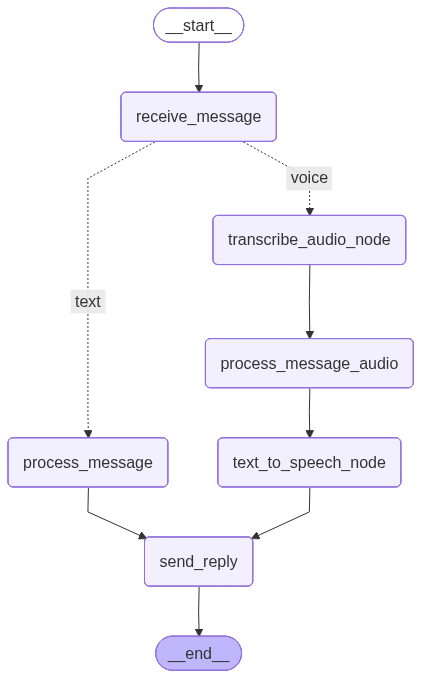

In [5]:
graph